# E-Commerce SQL Analytics — Python Analysis

## Business Context
Analysing the Olist Brazilian e-commerce dataset (100K+ orders, 2016-2018)
to surface revenue trends, seller performance, delivery insights,
and customer retention patterns.

**Tools:** SQL Server + Python (pandas, matplotlib, seaborn)  
**Analyst:** P.N. Jayawardene | **Date:** 2026

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import pyodbc
import warnings

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")

In [3]:
conn = pyodbc.connect(
    "DRIVER={SQL Server};"
    "SERVER=PIUMI\\SQLEXPRESS;"
    "DATABASE=OlistEcommerceDB;"
    "Trusted_Connection=yes;"
)

print("Connected to SQL Server successfully")

Connected to SQL Server successfully


In [4]:
df_orders = pd.read_sql(
    "SELECT * FROM dbo.vw_OrderSummary WHERE order_status = 'delivered'",
    conn
)

df_sellers = pd.read_sql(
    "SELECT * FROM dbo.vw_SellerPerformance WHERE Total_Orders >= 10",
    conn
)

print(f"Orders loaded: {len(df_orders):,}")
print(f"Sellers loaded: {len(df_sellers):,}")

df_orders.head()

Orders loaded: 101,325
Sellers loaded: 1,237


,order_id,customer_id,customer_unique_id,customer_city,customer_state,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,Order_YearMonth,Delivery_Days,Delivery_Status,Order_Revenue,payment_type,Review_Score
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,campos dos goytacazes,RJ,delivered,2017-09-13 08:59:02.0000000,2017-09-20 23:43:48.0000000,2017-09-29 00:00:00.0000000,2017-09,7.0,On Time,72.19,credit_card,5
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,eb28e67c4c0b83846050ddfb8a35d051,santa fe do sul,SP,delivered,2017-04-26 10:53:06.0000000,2017-05-12 16:04:24.0000000,2017-05-15 00:00:00.0000000,2017-04,16.0,On Time,259.83,credit_card,4
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,3818d81c6709e39d06b2738a8d3a2474,para de minas,MG,delivered,2018-01-14 14:33:31.0000000,2018-01-22 13:19:16.0000000,2018-02-05 00:00:00.0000000,2018-01,8.0,On Time,216.87,credit_card,5
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,af861d436cfc08b2c2ddefd0ba074622,atibaia,SP,delivered,2018-08-08 10:00:35.0000000,2018-08-14 13:32:39.0000000,2018-08-20 00:00:00.0000000,2018-08,6.0,On Time,25.78,credit_card,4
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,64b576fb70d441e8f1b2d7d446e483c5,varzea paulista,SP,delivered,2017-02-04 13:57:51.0000000,2017-03-01 16:42:31.0000000,2017-03-17 00:00:00.0000000,2017-02,25.0,On Time,218.04,credit_card,5


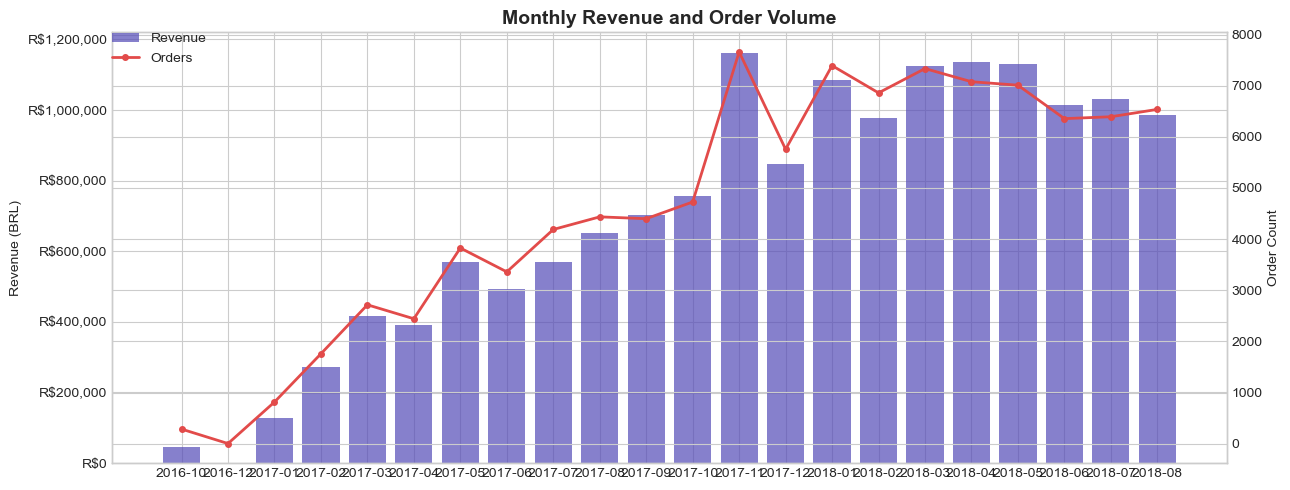

In [5]:
df_orders["order_purchase_timestamp"] = pd.to_datetime(
    df_orders["order_purchase_timestamp"]
)

monthly = df_orders.groupby("Order_YearMonth").agg(
    Revenue=("Order_Revenue", "sum"),
    Orders=("order_id", "count")
).reset_index().sort_values("Order_YearMonth")

fig, ax1 = plt.subplots(figsize=(13,5))

ax2 = ax1.twinx()

ax1.bar(
    monthly["Order_YearMonth"],
    monthly["Revenue"],
    color="#534AB7",
    alpha=0.7,
    label="Revenue"
)

ax2.plot(
    monthly["Order_YearMonth"],
    monthly["Orders"],
    color="#E24B4A",
    linewidth=2,
    marker="o",
    ms=4,
    label="Orders"
)

ax1.set_title(
    "Monthly Revenue and Order Volume",
    fontsize=14,
    fontweight="bold"
)

ax1.set_ylabel("Revenue (BRL)")
ax2.set_ylabel("Order Count")

ax1.yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x,_: f"R${x:,.0f}")
)

plt.xticks(rotation=45, ha="right", fontsize=8)

fig.legend(loc="upper left", bbox_to_anchor=(0.08,0.95))

plt.tight_layout()

plt.savefig(
    "../dashboards/screenshots/chart1_monthly_revenue.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

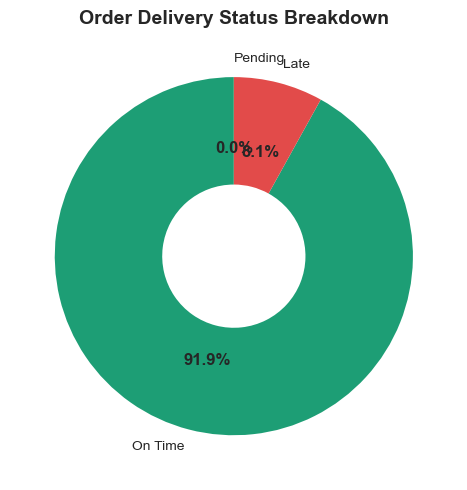

In [6]:
delivery = df_orders["Delivery_Status"].value_counts()

colors = {
    "On Time": "#1D9E75",
    "Late": "#E24B4A",
    "Pending": "#EF9F27"
}

fig, ax = plt.subplots(figsize=(7,5))

wedges, texts, autotexts = ax.pie(
    delivery.values,
    labels=delivery.index,
    autopct="%1.1f%%",
    colors=[colors.get(l, "#888780") for l in delivery.index],
    wedgeprops=dict(width=0.6),
    startangle=90
)

for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight("bold")

ax.set_title(
    "Order Delivery Status Breakdown",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "../dashboards/screenshots/chart2_delivery_status.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

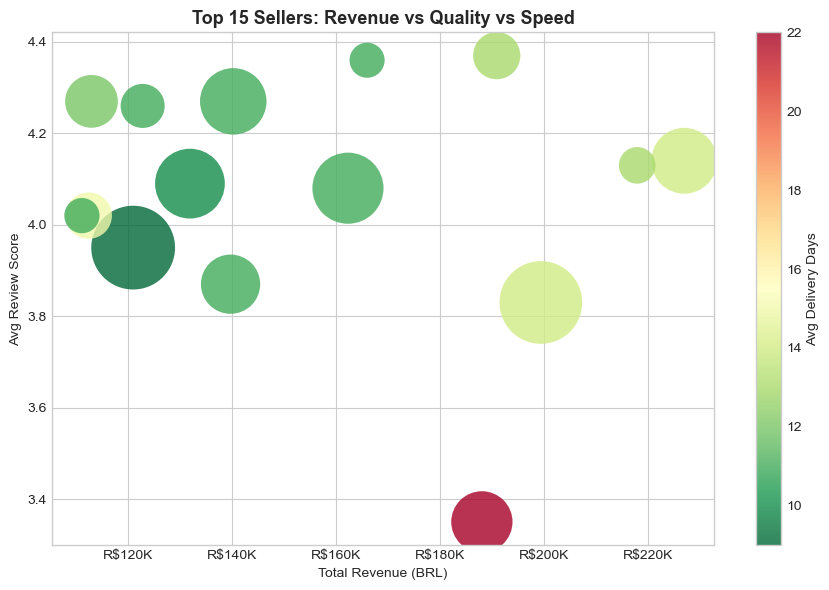

In [7]:
top_sellers = df_sellers.nlargest(15, "Total_Revenue")

fig, ax = plt.subplots(figsize=(9,6))

sc = ax.scatter(
    top_sellers["Total_Revenue"],
    top_sellers["Avg_Review_Score"],
    s=top_sellers["Total_Orders"] * 2,
    c=top_sellers["Avg_Delivery_Days"],
    cmap="RdYlGn_r",
    alpha=0.8,
    edgecolors="none"
)

plt.colorbar(sc, ax=ax, label="Avg Delivery Days")

ax.set_xlabel("Total Revenue (BRL)")
ax.set_ylabel("Avg Review Score")

ax.set_title(
    "Top 15 Sellers: Revenue vs Quality vs Speed",
    fontsize=13,
    fontweight="bold"
)

ax.xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x,_: f"R${x/1000:.0f}K")
)

plt.tight_layout()

plt.savefig(
    "../dashboards/screenshots/chart3_seller_scatter.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

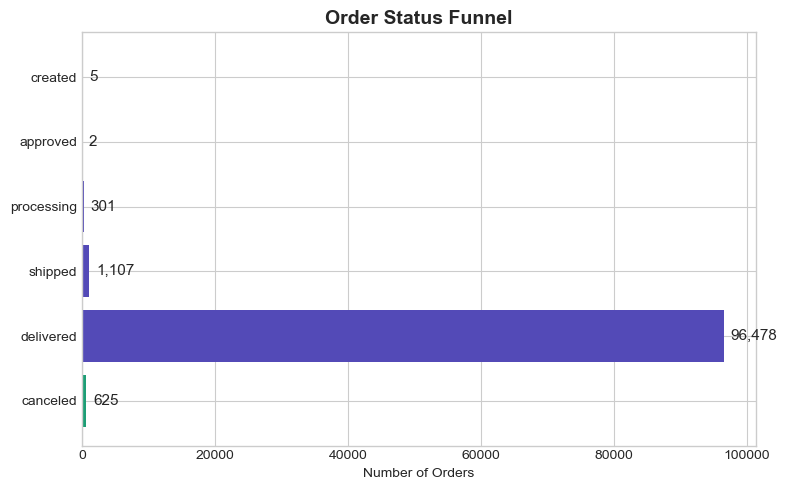

In [8]:
funnel_data = pd.read_sql("""
    SELECT order_status, COUNT(*) AS cnt
    FROM orders
    GROUP BY order_status
    ORDER BY cnt DESC
""", conn)

statuses = ["created", "approved", "processing", "shipped", "delivered", "canceled"]

funnel_filtered = funnel_data[funnel_data["order_status"].isin(statuses)]

funnel_filtered = funnel_filtered.set_index("order_status").reindex(
    [s for s in statuses if s in funnel_data["order_status"].values]
).dropna()

fig, ax = plt.subplots(figsize=(8,5))

bars = ax.barh(
    funnel_filtered.index[::-1],
    funnel_filtered["cnt"].values[::-1],
    color=["#1D9E75", "#534AB7", "#534AB7", "#534AB7", "#EF9F27", "#E24B4A"]
)

ax.bar_label(
    bars,
    padding=5,
    fontsize=11,
    labels=[f"{v:,}" for v in funnel_filtered["cnt"].values[::-1]]
)

ax.set_title("Order Status Funnel", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Orders")

plt.tight_layout()

plt.savefig(
    "../dashboards/screenshots/chart4_order_funnel.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## Key Findings

1. **Revenue peaked in November 2017** — likely due to Black Friday seasonal demand.
2. **Most delivered orders were completed on time** — showing strong operational performance.
3. **Seller performance varies clearly** — top sellers combine high revenue, good review scores, and faster delivery.
4. **Repeat purchase rate is low** — many customers buy only once.
5. **SP (São Paulo) dominates** — both in customer volume and seller activity.
6. **Delivery time varies by seller state** — remote states tend to have longer delivery times.

## Business Recommendations

- Prepare inventory and seller capacity before November sales peaks.
- Reward high-performing sellers with better platform visibility.
- Investigate sellers with high late-delivery rates.
- Build loyalty campaigns to convert one-time buyers into repeat customers.